In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import sentencepiece as spm

import math
import os
import re
import urllib.request
import zipfile
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# PE 구현

class PositionalEncoding(nn.Module):
    def __init__(self, position, d_model):
        super(PositionalEncoding, self).__init__()
        self.d_model = d_model
        self.position = position

        self.pos_encoding = self._build_pos_encoding(position, d_model)

    def _get_angles(self, position, i, d_model):
        return 1.0 / (10000.0 ** ((2.0 * (i // 2)) / d_model)) * position

    def _build_pos_encoding(self, position, d_model):
        pos = torch.arange(position, dtype=torch.float32).unsqueeze(1)
        i = torch.arange(d_model, dtype=torch.float32).unsqueeze(0)

        angle_rads = self._get_angles(pos, i, d_model)
        sines = torch.sin(angle_rads[:, 0::2])
        cosines = torch.cos(angle_rads[:, 1::2])

        pos_encoding = torch.zeros(position, d_model)
        pos_encoding[:, 0::2] = sines
        pos_encoding[:, 1::2] = cosines

        pos_encoding = pos_encoding.unsqueeze(0)  # shape: [1, position, d_model]
        return pos_encoding

    def forward(self, x):
        return x + self.pos_encoding[:, :x.size(1), :].to(x.device)

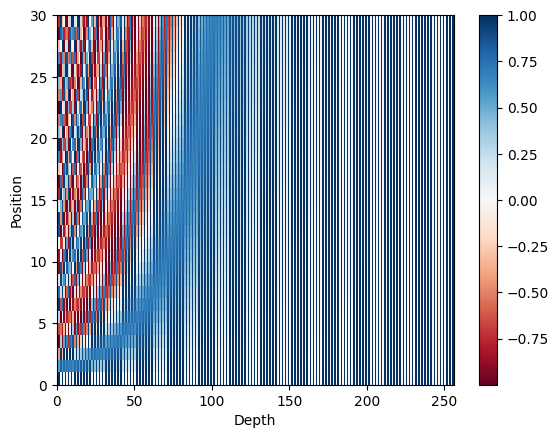

In [3]:
# PE 시각화 

sample_pos_encoding = PositionalEncoding(30, 256)

plt.pcolormesh(sample_pos_encoding.pos_encoding.numpy()[0], cmap='RdBu')
plt.xlabel('Depth')
plt.xlim((0, 256))
plt.ylabel('Position')
plt.colorbar()
plt.show()

In [4]:
# scaled dot product attention

def scaled_dot_product_attention(query, key, value, mask=None):

    # 1) Q와 K의 내적을 통해 score(유사도) 계산
    # key.transpose(-1, -2): (batch_size, heads, depth, seq_len)
    # matmul 결과 shape: (batch_size, heads, seq_len, seq_len)
    matmul_qk = torch.matmul(query, key.transpose(-1, -2))

    # 2) depth에 따라 정규화
    depth = key.size(-1)  # depth = d_model / heads
    logits = matmul_qk / math.sqrt(depth)

    # 3) 마스크가 주어졌다면 -1e9(아주 작은 값)를 더해 소프트맥스에서 제외시키도록 함
    if mask is not None:
        # 텐서플로우: logits += (mask * -1e9)
        # 파이토치 동일 적용
        logits = logits + (mask * -1e9)

    # 4) 소프트맥스 계산해 attention weights 생성
    attention_weights = F.softmax(logits, dim=-1)

    # 5) attention weights와 value의 내적
    output = torch.matmul(attention_weights, value)

    return output, attention_weights

In [5]:
# multi head attention
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, name="multi_head_attention"):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model은 num_heads로 나누어떨어져야 함
        assert d_model % num_heads == 0

        self.depth = d_model // num_heads

        # 파이토치에서 Dense는 nn.Linear로 대응
        self.query_dense = nn.Linear(d_model, d_model)
        self.key_dense = nn.Linear(d_model, d_model)
        self.value_dense = nn.Linear(d_model, d_model)

        self.out_dense = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        """
        x: (batch_size, seq_len, d_model)
        => (batch_size, num_heads, seq_len, depth) 형태로 변환
        """
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)  # (batch_size, num_heads, seq_len, depth)
        return x

    def forward(self, query, key, value, mask=None):
        """
        query, key, value: (batch_size, seq_len, d_model)
        mask: (batch_size, 1, seq_len, seq_len) 등으로 broadcast 가능하도록 구성
        """
        batch_size = query.size(0)

        # Q, K, V에 각각 Linear 적용
        query = self.query_dense(query)
        key = self.key_dense(key)
        value = self.value_dense(value)

        # Head 분할
        query = self.split_heads(query, batch_size)
        key = self.split_heads(key, batch_size)
        value = self.split_heads(value, batch_size)

        # 스케일드 닷 프로덕트 어텐션
        scaled_attention, _ = scaled_dot_product_attention(query, key, value, mask)

        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        scaled_attention = scaled_attention.permute(0, 2, 1, 3).contiguous()

        # 다시 (batch_size, seq_len, d_model)로 합치기
        concat_attention = scaled_attention.view(batch_size, -1, self.d_model)

        # 최종 Dense
        output = self.out_dense(concat_attention)
        return output


In [6]:
def create_padding_mask(x): # <PAD> 마스킹 
    # x == 0 위치를 찾아 float형 1로 변환
    mask = (x == 0).float()
    # (batch_size, seq_len) -> (batch_size, 1, 1, seq_len)
    mask = mask.unsqueeze(1).unsqueeze(2)
    return mask

In [7]:
x = torch.tensor([[1, 2, 0, 3, 0],
                  [0, 0, 0, 4, 5]])
mask = create_padding_mask(x)
print("입력 텐서 크기 :", x.shape)    # (2, 5)
print("생성된 마스크 크기 :", mask.shape)  # (2, 1, 1, 5)
print(mask)

입력 텐서 크기 : torch.Size([2, 5])
생성된 마스크 크기 : torch.Size([2, 1, 1, 5])
tensor([[[[0., 0., 1., 0., 1.]]],


        [[[1., 1., 1., 0., 0.]]]])


In [8]:
# look ahead masking
def create_look_ahead_mask(x):
    seq_len = x.size(1)

    # (seq_len, seq_len) 크기의 하삼각 행렬(tril) 생성 후 1에서 빼서
    # 상삼각이 1, 하삼각(자기 자신 포함)이 0이 되도록 설정
    # => 미래 토큰(자신 인덱스보다 큰 위치) 마스킹
    look_ahead_mask = 1 - torch.tril(torch.ones((seq_len, seq_len)))

    # 패딩 마스크 생성 (shape: (batch_size, 1, 1, seq_len))
    padding_mask = create_padding_mask(x)

    # look_ahead_mask: (seq_len, seq_len) -> (1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(0)
    # -> (1, seq_len, seq_len) -> (1, 1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(1)
    look_ahead_mask = look_ahead_mask.to(x.device)

    # look-ahead 마스크와 패딩 마스크를 합성 (둘 중 하나라도 1이면 마스킹)
    # 최종 shape은 브로드캐스팅으로 (batch_size, 1, seq_len, seq_len)
    combined_mask = torch.max(look_ahead_mask, padding_mask)
    return combined_mask

In [9]:
x = torch.tensor([[1, 2, 3, 4, 5]])
mask_1 = create_look_ahead_mask(x)
print("첫 번째 시퀀스:\n", mask_1, mask_1.shape)

첫 번째 시퀀스:
 tensor([[[[0., 1., 1., 1., 1.],
          [0., 0., 1., 1., 1.],
          [0., 0., 0., 1., 1.],
          [0., 0., 0., 0., 1.],
          [0., 0., 0., 0., 0.]]]]) torch.Size([1, 1, 5, 5])


In [10]:
x2 = torch.tensor([[0, 5, 1, 5, 5]])
mask_2 = create_look_ahead_mask(x2)
print("두 번째 시퀀스:\n", mask_2, mask_2.shape)

두 번째 시퀀스:
 tensor([[[[1., 1., 1., 1., 1.],
          [1., 0., 1., 1., 1.],
          [1., 0., 0., 1., 1.],
          [1., 0., 0., 0., 1.],
          [1., 0., 0., 0., 0.]]]]) torch.Size([1, 1, 5, 5])


In [11]:
# Self Attention & FF 
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(EncoderLayer, self).__init__()
        self.mha = MultiHeadAttention(d_model, num_heads)  # 이전에 구현한 MHA
        self.dropout1 = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        # 피드포워드 부분 (Dense -> ReLU -> Dense)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, d_model)
        )
        self.dropout2 = nn.Dropout(dropout)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, mask=None):
        # (1) 멀티 헤드 어텐션 (셀프 어텐션)
        attn_output = self.mha(x, x, x, mask)  # (batch_size, seq_len, d_model)
        attn_output = self.dropout1(attn_output)
        out1 = self.norm1(x + attn_output)     # 잔차 연결 + LayerNorm

        # (2) 피드포워드 신경망
        ffn_output = self.ffn(out1)            # (batch_size, seq_len, d_model)
        ffn_output = self.dropout2(ffn_output)
        out2 = self.norm2(out1 + ffn_output)   # 잔차 연결 + LayerNorm

        return out2


In [12]:
class Encoder(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,
                 ff_dim,
                 d_model,
                 num_heads,
                 dropout=0.1):
        super(Encoder, self).__init__()
        self.d_model = d_model

        # (1) 임베딩 레이어
        self.embedding = nn.Embedding(vocab_size, d_model)

        # (2) 포지셔널 인코딩
        self.pos_encoding = PositionalEncoding(position=vocab_size, d_model=d_model)

        self.dropout = nn.Dropout(dropout)

        # (3) EncoderLayer 쌓기
        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, mask=None):
        # (1) 임베딩 & sqrt(d_model)로 스케일링
        x = self.embedding(x) * math.sqrt(self.d_model)

        # (2) 포지셔널 인코딩 적용 + 드롭아웃
        x = self.pos_encoding(x)  # shape: (batch_size, seq_len, d_model)
        x = self.dropout(x)

        # (3) num_layers만큼 쌓아올린 EncoderLayer 통과
        for layer in self.enc_layers:
            x = layer(x, mask)

        return x

In [13]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(DecoderLayer, self).__init__()

        # 첫 번째 서브 레이어 (디코더 내부 셀프 어텐션)
        self.self_mha = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        # 두 번째 서브 레이어 (인코더-디코더 어텐션)
        self.encdec_mha = MultiHeadAttention(d_model, num_heads)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

        # 세 번째 서브 레이어 (피드포워드 네트워크)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),  # Dense(units=ff_dim)
            nn.ReLU(),                   # activation='relu'
            nn.Linear(ff_dim, d_model)   # Dense(units=d_model)
        )
        self.norm3 = nn.LayerNorm(d_model, eps=1e-6)

        # 드롭아웃
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        # 1) 셀프 어텐션 (디코더 내부)
        self_attn_out = self.self_mha(x, x, x, mask=look_ahead_mask)
        self_attn_out = self.dropout1(self_attn_out)
        out1 = self.norm1(x + self_attn_out)  # 잔차 연결 + LayerNorm

        # 2) 인코더-디코더 어텐션
        encdec_attn_out = self.encdec_mha(out1, enc_outputs, enc_outputs, mask=padding_mask)
        encdec_attn_out = self.dropout2(encdec_attn_out)
        out2 = self.norm2(out1 + encdec_attn_out)  # 잔차 연결 + LayerNorm

        # 3) 피드포워드 (Dense -> ReLU -> Dense)
        ffn_out = self.ffn(out2)
        ffn_out = self.dropout3(ffn_out)
        out3 = self.norm3(out2 + ffn_out)  # 잔차 연결 + LayerNorm

        return out3

In [14]:
class Decoder(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,
                 ff_dim,
                 d_model,
                 num_heads,
                 dropout=0.5):
        super(Decoder, self).__init__()
        self.d_model = d_model

        # (1) 임베딩 레이어
        self.embedding = nn.Embedding(vocab_size, d_model)

        # (2) 포지셔널 인코딩
        # 실제 학습 시에는 최대 시퀀스 길이에 맞추어 쓰기도 함
        self.pos_encoding = PositionalEncoding(position=vocab_size, d_model=d_model)

        self.dropout = nn.Dropout(dropout)

        # (3) DecoderLayer 쌓기
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        # (1) 임베딩 + sqrt(d_model)로 스케일링
        x = self.embedding(x) * math.sqrt(self.d_model)

        # (2) 포지셔널 인코딩 + 드롭아웃
        x = self.pos_encoding(x)    # (batch_size, tgt_seq_len, d_model)
        x = self.dropout(x)

        # (3) num_layers만큼 쌓인 DecoderLayer 통과
        for layer in self.dec_layers:
            x = layer(x, enc_outputs, look_ahead_mask, padding_mask)

        return x

여기서는 Cornell Movie-Dialogs Corpus라는 영화 및 TV 프로그램에서 사용되었던 대화의 쌍으로 구성된 데이터셋을 사용합니다. 대화의 쌍이라고 하는 것은 기본적으로 먼저 말하는 사람의 대화 문장이 있고, 그에 응답하는 대화 문장의 쌍으로 이루어집니다.  

데이터를 받아오는 이번 스텝에서 목표로 하는 것은 다음과 같습니다.  
  
정해진 개수인 50,000개의 질문과 답변의 쌍을 추출한다.   
문장에서 단어와 구두점 사이에 공백을 추가한다.  
알파벳과 ! ? , . 이 4개의 구두점을 제외하고 다른 특수문자는 모두 제거한다.  

In [15]:
import os
import urllib.request
import zipfile
import pandas as pd

# 코넬 대사 데이터셋 다운로드 URL
url = 'http://www.cs.cornell.edu/~cristian/data/cornell_movie_dialogs_corpus.zip'

# ~/data 경로
data_dir = os.path.join(os.getenv('HOME'), 'data')
os.makedirs(data_dir, exist_ok=True)

# ZIP 파일을 ~/data 안에 저장
zip_filename = os.path.join(data_dir, 'cornell_movie_dialogs.zip')

# 이미 ZIP 파일이 없는 경우에만 다운로드
if not os.path.exists(zip_filename):
    print(f"Downloading {zip_filename} ...")
    urllib.request.urlretrieve(url, zip_filename)
    print("Download complete.")
else:
    print(f"Already exists: {zip_filename}")

# 압축 해제될 데이터셋 폴더 경로
path_to_dataset = os.path.join(data_dir, "cornell movie-dialogs corpus")

# 데이터셋 폴더가 없을 때만 압축 해제
if not os.path.exists(path_to_dataset):
    print(f"Extracting to {data_dir} ...")
    with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
        zip_ref.extractall(data_dir)
    print("Extract complete.")
else:
    print(f"Already extracted: {path_to_dataset}")

# 개별 파일 경로 설정
path_to_movie_lines = os.path.join(path_to_dataset, 'movie_lines.txt')
path_to_movie_conversations = os.path.join(path_to_dataset, 'movie_conversations.txt')

print("path_to_dataset:", path_to_dataset)
print("path_to_movie_lines:", path_to_movie_lines)
print("path_to_movie_conversations:", path_to_movie_conversations)

Already exists: /home/thkim0/data/cornell_movie_dialogs.zip
Already extracted: /home/thkim0/data/cornell movie-dialogs corpus
path_to_dataset: /home/thkim0/data/cornell movie-dialogs corpus
path_to_movie_lines: /home/thkim0/data/cornell movie-dialogs corpus/movie_lines.txt
path_to_movie_conversations: /home/thkim0/data/cornell movie-dialogs corpus/movie_conversations.txt


~/data/cornell_movie_dialogs.zip  
~/data/cornell movie-dialogs corpus/movie_lines.txt  
~/data/cornell movie-dialogs corpus/movie_conversations.txt  

In [16]:
MAX_SAMPLES = 100000

In [17]:
# 전처리 함수
def preprocess_sentence(sentence):
  # 입력받은 sentence를 소문자로 변경하고 양쪽 공백을 제거
  sentence = sentence.lower().strip()

  # 단어와 구두점(punctuation) 사이의 거리를 만듭니다.
  # 예를 들어서 "I am a student." => "I am a student ."와 같이
  # student와 온점 사이에 거리를 만듭니다.
  sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
  sentence = re.sub(r'[" "]+', " ", sentence)

  # (a-z, A-Z, ".", "?", "!", ",")를 제외한 모든 문자를 공백인 ' '로 대체합니다.
  sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)
  sentence = sentence.strip()
  return sentence
print("슝=3")

sample_sentence = "안녕하세요? Hello! I'm a student😊, nice to meet you!"

preprocessed_sentence = preprocess_sentence(sample_sentence)
print(preprocessed_sentence)

슝=3
? hello ! i m a student , nice to meet you !


In [18]:
def read_cornell_data(path_to_movie_lines, path_to_movie_conversations, max_samples=50000):
    id2line = {}
    with open(path_to_movie_lines, 'r', errors='ignore') as f:
        lines = f.readlines()
    for line in lines:
        parts = line.strip().split(" +++$+++ ")
        if len(parts) >= 5:
            line_id = parts[0]
            text = parts[4]
            id2line[line_id] = text

    pairs = []
    with open(path_to_movie_conversations, 'r', errors='ignore') as f:
        conv_lines = f.readlines()
    for line in conv_lines:
        parts = line.strip().split(" +++$+++ ")
        if len(parts) < 4:
            continue
        # 대화 ID 목록 추출: ["L1045","L1044","L1043", ...]
        conv_str = parts[3]
        conv_list = conv_str[1:-1].split(", ")
        conv_list = [c.strip("'") for c in conv_list]  # "'L1045'" -> "L1045"

        # 연속된 두 문장씩 (질문, 답변) 구성
        for i in range(len(conv_list) - 1):
            q_id = conv_list[i]
            a_id = conv_list[i+1]
            q_text = id2line.get(q_id, "")
            a_text = id2line.get(a_id, "")
            # 간단 전처리(소문자 변환 정도만 예시)
            q_text = preprocess_sentence(q_text)
            a_text = preprocess_sentence(a_text)

            pairs.append((q_text, a_text))
            if len(pairs) >= max_samples:
                return pairs
    return pairs

In [19]:
pairs = read_cornell_data(path_to_movie_lines, path_to_movie_conversations, max_samples=MAX_SAMPLES)

print('전체 샘플 수 :', len(pairs))

전체 샘플 수 : 100000


12. 병렬 데이터 전처리하기  
질문과 답변의 셋을 각각 pairs에 저장하였으므로, 본격적으로 전처리를 진행해보겠습니다. 이번 스텝에서 진행할 전체적인 과정을 요약하면 다음과 같습니다.  
   
Google SentencePiece 를 토크나이저로 사용한다.  
단어보다 더 작은 단위인 Subword를 기준으로 토크나이징하고, 각 토큰을 고유한 정수로 인코딩 한다.  
각 문장을 토큰화하고 각 문장의 시작과 끝을 나타내는 START_TOKEN 및 END_TOKEN을 추가한다.  
최대 길이 MAX_LENGTH 인 40을 넘는 문장들은 필터링한다.  
MAX_LENGTH보다 길이가 짧은 문장들은 40에 맞도록 패딩 한다.

In [20]:
corpus_file = "clean_corpus.txt"
with open(corpus_file, 'w', encoding='utf-8') as f:
    for q, a in pairs:
        f.write(q + "\n")
        f.write(a + "\n")

In [21]:
spm.SentencePieceTrainer.Train(
    input=corpus_file,
    model_prefix="spm_cornell",
    vocab_size=8000,
    character_coverage=1.0,
    model_type="bpe",
    max_sentence_length=999999,
    bos_id=1,  # <s> (Beginning of Sentence) 설정
    eos_id=2,  # </s> (End of Sentence) 설정
    pad_id=0,  # Padding ID 설정
    unk_id=3   # Unknown Token ID 설정
)


sentencepiece_trainer.cc(77) LOG(INFO) Starts training with : 
trainer_spec {
  input: clean_corpus.txt
  input_format: 
  model_prefix: spm_cornell
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 1
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 999999
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  differential_privacy_noise_level: 0
  differential_privacy_clippi

In [22]:
sp = spm.SentencePieceProcessor()
sp.Load("spm_cornell.model")

True

In [23]:
# 예제 문장
sentence = "I'm learning PyTorch with SentencePiece!"

sentence = preprocess_sentence(sentence)
print("전처리 후의 문장:", sentence)

# 1. 토크나이징 (subword 단위로 분할)
tokens = sp.encode(sentence, out_type=str)
print("Tokenized:", tokens)

# 2. 인코딩 (서브워드를 정수 ID로 변환)
encoded = sp.encode(sentence, out_type=int)
print("Encoded:", encoded)

# 3. 디코딩 (정수 ID → 원본 문장 복원)
decoded = sp.decode(encoded)
print("Decoded:", decoded)


전처리 후의 문장: i m learning pytorch with sentencepiece !
Tokenized: ['▁i', '▁m', '▁learning', '▁p', 'y', 'tor', 'ch', '▁with', '▁sentence', 'p', 'iece', '▁!']
Encoded: [6, 13, 4658, 37, 7983, 3279, 118, 113, 6005, 7990, 4476, 69]
Decoded: i m learning pytorch with sentencepiece !


질문과 답변의 쌍을 Dataset 의 입력으로 사용하여 파이프라인을 구성합니다. 이때, 교사  강요를 위해서 answers[:, :-1]를 디코더의 입력값, answers[:, 1:]를 디코더의 레이블로 사용합니다.  

데이터를 로드하는 동시에 전처리 함수를 호출하여 질문과 답변의 쌍을 전처리합니다.

In [24]:
class CornellDataset(Dataset):
    def __init__(self, pairs, sp, max_length=40):
        super().__init__()
        self.sp = sp
        self.max_length = max_length
        self.data = []

        for q_text, a_text in pairs:
            # 1) 토크나이즈
            q_ids = sp.EncodeAsIds(q_text)
            a_ids = sp.EncodeAsIds(a_text)

            # 2) [CLS]/[SEP] 같은 별도 스페셜 토큰을 쓸 수도 있으나,
            #    여기서는 SentencePiece 기본 <s>, </s> 등 혹은 사용자 정의 토큰 활용 가능
            #    간단히 <s>=sp.bos_id(), </s>=sp.eos_id()로 가정해본다면:
            #    sp.SetEncodeExtraOptions("bos:eos") 등으로 설정하는 방법도 있음.
            # 여기서는 수동으로 bos/eos id를 붙인다고 가정
            bos_id = sp.bos_id() if sp.bos_id() >= 0 else 1  # 혹은 임의값
            eos_id = sp.eos_id() if sp.eos_id() >= 0 else 2

            q_tokens = [bos_id] + q_ids + [eos_id]
            a_tokens = [bos_id] + a_ids + [eos_id]

            # 3) 길이 제한
            if len(q_tokens) > max_length or len(a_tokens) > max_length:
                continue

            # 4) 고정 길이 패딩
            q_tokens += [0]*(max_length - len(q_tokens))  # 0 -> <pad> 가정
            a_tokens += [0]*(max_length - len(a_tokens))

            # 5) 디코더 입력(dec_input): a_tokens[:-1], 타겟(outputs): a_tokens[1:]
            #    (teacher forcing용)
            dec_input = a_tokens[:-1]
            target = a_tokens[1:]

            self.data.append({
                "enc_input": q_tokens,
                "dec_input": dec_input,
                "target": target
            })

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        enc_input = torch.tensor(sample["enc_input"], dtype=torch.long)
        dec_input = torch.tensor(sample["dec_input"], dtype=torch.long)
        target = torch.tensor(sample["target"], dtype=torch.long)
        return enc_input, dec_input, target

In [25]:
dataset = CornellDataset(pairs, sp, max_length=40)

In [26]:
for encoder_input, decoder_input, decoder_label  in dataset:
    print("텐서 크기 :",encoder_input.size())
    print(encoder_input)
    print(sp.decode(encoder_input.tolist()))
    print(decoder_input)
    print(sp.decode(decoder_input.tolist()))
    print(decoder_label)
    print(sp.decode(decoder_label.tolist()))
    break

텐서 크기 : torch.Size([40])
tensor([   1,  116,   51,  318,   99, 1645,   24,  305, 7997,   33, 1216,   62,
          36, 7978,  264,   58, 6864,  838, 4131,  121, 1073,   39, 3574, 2641,
         119, 1309,   14,  140,  300, 1772,  862,  160,   72,   19, 6834,    4,
         452,    4,    2,    0])
can we make this quick ? roxanne korrine and andrew barrett are having an incredibly horrendous public break up on the quad . again .
tensor([  1, 181,  17,   6, 439,  51,  20, 539, 113, 518,  21, 182, 532, 276,
         17, 157,  55,  10, 364, 113,  15,   4,   2,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0])
well , i thought we d start with pronunciation , if that s okay with you .
tensor([181,  17,   6, 439,  51,  20, 539, 113, 518,  21, 182, 532, 276,  17,
        157,  55,  10, 364, 113,  15,   4,   2,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0])
well , i thought we d start with pronunciation , if t

In [27]:
print(sp.id_to_piece(1))  # <s>
print(sp.id_to_piece(2))  # </s>

<s>
</s>


In [28]:
from torch.utils.data import random_split

BATCH_SIZE = 32
VAL_RATIO = 0.2
SEED = 42

val_size = int(len(dataset) * VAL_RATIO)
train_size = len(dataset) - val_size

generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=generator
)

pin_memory = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=pin_memory
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=pin_memory
)

print(f"train samples: {len(train_dataset)}")
print(f"validation samples: {len(val_dataset)}")


train samples: 70353
validation samples: 17588


In [29]:
for loader_name, loader in [("train", train_loader), ("validation", val_loader)]:
    for encoder_input, decoder_input, decoder_label in loader:
        print(f"[{loader_name}] encoder_input:", encoder_input.size())
        print(f"[{loader_name}] decoder_input:", decoder_input.size())
        print(f"[{loader_name}] decoder_label:", decoder_label.size())
        break


[train] encoder_input: torch.Size([32, 40])
[train] decoder_input: torch.Size([32, 39])
[train] decoder_label: torch.Size([32, 39])
[validation] encoder_input: torch.Size([32, 40])
[validation] decoder_input: torch.Size([32, 39])
[validation] decoder_label: torch.Size([32, 39])


In [30]:
class Transformer(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,      # 인코더/디코더 층 수
                 units,           # feed-forward 네트워크의 중간 차원(ff_dim)
                 d_model,         # 임베딩 및 내부 표현 차원
                 num_heads,       # 멀티헤드 어텐션의 헤드 수
                 dropout=0.1):
        super(Transformer, self).__init__()

        # 인코더
        self.encoder = Encoder(
            vocab_size=vocab_size,
            num_layers=num_layers,
            ff_dim=units,
            d_model=d_model,
            num_heads=num_heads,
            dropout=dropout
        )

        # 디코더
        self.decoder = Decoder(
            vocab_size=vocab_size,
            num_layers=num_layers,
            ff_dim=units,
            d_model=d_model,
            num_heads=num_heads,
            dropout=dropout
        )

        # 최종 출력층: (d_model) -> (vocab_size)
        self.final_linear = nn.Linear(d_model, vocab_size)

        # 참고: 텐서플로우 코드의 `name="transformer"`는 파이토치에선 보통 사용 안 함

    def forward(self, inputs, dec_inputs):
        # 1) 인코더 패딩 마스크 생성
        enc_padding_mask = create_padding_mask(inputs)     # shape (batch_size, 1, 1, src_seq_len)

        # 2) 디코더 look-ahead + 패딩 마스크
        look_ahead_mask = create_look_ahead_mask(dec_inputs)  # shape (batch_size, 1, tgt_seq_len, tgt_seq_len)

        # 3) 디코더에서 인코더 출력 쪽을 마스킹할 때 쓸 패딩 마스크
        dec_padding_mask = create_padding_mask(inputs)        # shape (batch_size, 1, 1, src_seq_len)

        # 4) 인코더 수행
        enc_outputs = self.encoder(
            x=inputs,
            mask=enc_padding_mask
        )  # shape: (batch_size, src_seq_len, d_model)

        # 5) 디코더 수행
        dec_outputs = self.decoder(
            x=dec_inputs,           # (batch_size, tgt_seq_len)
            enc_outputs=enc_outputs,# (batch_size, src_seq_len, d_model)
            look_ahead_mask=look_ahead_mask,
            padding_mask=dec_padding_mask
        )  # shape: (batch_size, tgt_seq_len, d_model)

        # 6) 최종 Dense (vocab_size)
        logits = self.final_linear(dec_outputs)  # (batch_size, tgt_seq_len, vocab_size)
        return logits

In [31]:
# 예: 하이퍼파라미터 설정
NUM_LAYERS = 6     # 인코더/디코더 층 수
D_MODEL = 512      # 임베딩 및 내부 표현 차원
NUM_HEADS = 8      # 멀티헤드 어텐션에서의 헤드 수
UNITS = 2048        # 피드포워드 신경망의 은닉 차원
DROPOUT = 0.1      # 드롭아웃 비율
VOCAB_SIZE = 8000 # 단어 집합 크기(예시)

# 모델 생성
model = Transformer(
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS,
    units=UNITS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dropout=DROPOUT
)

print(model)

loss_function = nn.CrossEntropyLoss(ignore_index=sp.pad_id())

Transformer(
  (encoder): Encoder(
    (embedding): Embedding(8000, 512)
    (pos_encoding): PositionalEncoding()
    (dropout): Dropout(p=0.1, inplace=False)
    (enc_layers): ModuleList(
      (0-5): 6 x EncoderLayer(
        (mha): MultiHeadAttention(
          (query_dense): Linear(in_features=512, out_features=512, bias=True)
          (key_dense): Linear(in_features=512, out_features=512, bias=True)
          (value_dense): Linear(in_features=512, out_features=512, bias=True)
          (out_dense): Linear(in_features=512, out_features=512, bias=True)
        )
        (dropout1): Dropout(p=0.1, inplace=False)
        (norm1): LayerNorm((512,), eps=1e-06, elementwise_affine=True)
        (ffn): Sequential(
          (0): Linear(in_features=512, out_features=2048, bias=True)
          (1): ReLU()
          (2): Linear(in_features=2048, out_features=512, bias=True)
        )
        (dropout2): Dropout(p=0.1, inplace=False)
        (norm2): LayerNorm((512,), eps=1e-06, elementwise_a

In [32]:
# adam with custom LR scheduling
def get_lr_lambda(d_model, warmup_steps=4000):
    d_model = float(d_model)
    def lr_lambda(step):
        # step은 0부터 시작하므로 +1로 보정
        step = step + 1
        return (d_model ** -0.5) * min(step ** -0.5, step * (warmup_steps ** -1.5))
    return lr_lambda

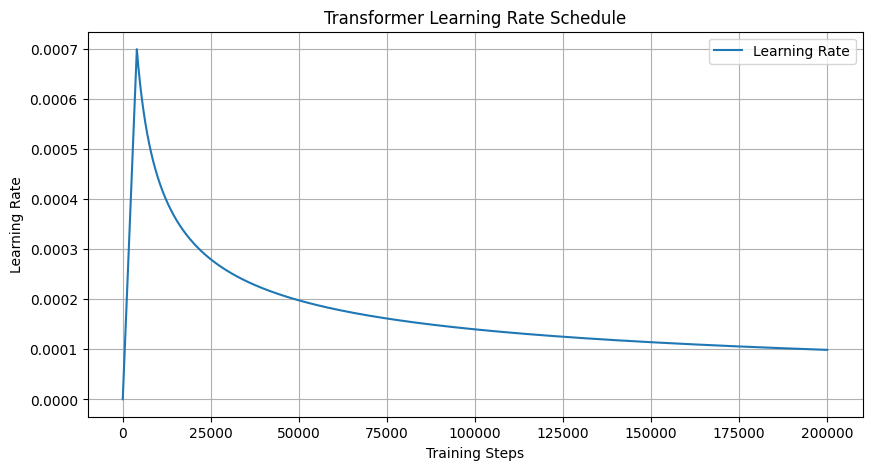

In [33]:
# 하이퍼파라미터 설정
d_model = 512
warmup_steps = 4000
total_steps = 200000  # 총 학습 스텝

# 학습률 스케줄 시각화
steps = np.arange(1, total_steps + 1)
learning_rates = [get_lr_lambda(d_model, warmup_steps)(step) for step in steps]

# 그래프 출력
plt.figure(figsize=(10, 5))
plt.plot(steps, learning_rates, label="Learning Rate")
plt.xlabel("Training Steps")
plt.ylabel("Learning Rate")
plt.title("Transformer Learning Rate Schedule")
plt.legend()
plt.grid(True)
plt.show()


In [34]:
# Optimizer 정의
optimizer = optim.Adam(model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)

# Scheduler 정의: Transformer warmup schedule은 epoch가 아니라 batch step마다 업데이트합니다.
scheduler = lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr_lambda(D_MODEL, warmup_steps=4000))


def accuracy_counts(logits, target, pad_id=0):
    """
    logits: (batch_size, seq_len, vocab_size)
    target: (batch_size, seq_len)

    batch 평균 accuracy가 아니라 non-PAD token 수 기준으로 누적할 수 있도록
    맞힌 token 수와 전체 non-PAD token 수를 반환합니다.
    """
    preds = logits.argmax(dim=-1)
    mask = (target != pad_id)

    correct = ((preds == target) & mask).sum().item()
    total = mask.sum().item()

    return correct, total


In [35]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = model.to(device)

In [36]:
def train_one_epoch(model, train_loader, optimizer, loss_function, scheduler, device, pad_id):
    model.train()

    loss_sum = 0.0
    correct_sum = 0
    token_sum = 0

    for step, batch in enumerate(train_loader, start=1):
        enc_input, dec_input, target = [x.to(device) for x in batch]
        token_count = (target != pad_id).sum().item()

        optimizer.zero_grad(set_to_none=True)

        logits = model(enc_input, dec_input)
        loss = loss_function(logits.permute(0, 2, 1), target)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        correct, total = accuracy_counts(logits, target, pad_id=pad_id)

        loss_sum += loss.item() * token_count
        correct_sum += correct
        token_sum += total

        if step % 100 == 0:
            step_acc = correct / total if total > 0 else 0.0
            print(
                f"  Step {step:04d} | "
                f"Loss: {loss.item():.4f} | "
                f"Token Acc: {step_acc:.4f} | "
                f"LR: {scheduler.get_last_lr()[0]:.8f}"
            )

    epoch_loss = loss_sum / token_sum if token_sum > 0 else 0.0
    epoch_acc = correct_sum / token_sum if token_sum > 0 else 0.0

    return epoch_loss, epoch_acc


def evaluate(model, val_loader, loss_function, device, pad_id):
    model.eval()

    loss_sum = 0.0
    correct_sum = 0
    token_sum = 0

    with torch.no_grad():
        for batch in val_loader:
            enc_input, dec_input, target = [x.to(device) for x in batch]
            token_count = (target != pad_id).sum().item()

            logits = model(enc_input, dec_input)
            loss = loss_function(logits.permute(0, 2, 1), target)

            correct, total = accuracy_counts(logits, target, pad_id=pad_id)

            loss_sum += loss.item() * token_count
            correct_sum += correct
            token_sum += total

    epoch_loss = loss_sum / token_sum if token_sum > 0 else 0.0
    epoch_acc = correct_sum / token_sum if token_sum > 0 else 0.0

    return epoch_loss, epoch_acc


In [37]:
import os
import pandas as pd


def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    loss_function,
    scheduler,
    num_epochs,
    device,
    pad_id,
    patience=5,
    min_delta=0.0,
    history_dir="./histories",
    model_name="transformer_cornell_spm"
):
    os.makedirs(history_dir, exist_ok=True)

    history_path = os.path.join(history_dir, f"history_{model_name}.csv")
    checkpoint_path = os.path.join(history_dir, f"{model_name}_best.pt")

    model.to(device)

    history = []
    best_val_loss = float("inf")
    patience_counter = 0

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model=model,
            train_loader=train_loader,
            optimizer=optimizer,
            loss_function=loss_function,
            scheduler=scheduler,
            device=device,
            pad_id=pad_id
        )

        val_loss, val_acc = evaluate(
            model=model,
            val_loader=val_loader,
            loss_function=loss_function,
            device=device,
            pad_id=pad_id
        )

        improved = val_loss < best_val_loss - min_delta

        if improved:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            patience_counter += 1

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "best_val_loss": best_val_loss,
            "patience_counter": patience_counter,
            "learning_rate": scheduler.get_last_lr()[0],
            "is_best": improved,
        }
        history.append(row)

        history_df = pd.DataFrame(history)
        history_df.to_csv(history_path, index=False)

        print(
            f"Epoch {epoch:02d}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"LR: {scheduler.get_last_lr()[0]:.8f}"
        )

        if improved:
            print(f"  -> Best model saved: {checkpoint_path}")
        else:
            print(f"  -> EarlyStopping counter: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch}")
            break

    if os.path.exists(checkpoint_path):
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        model.to(device)
        print(f"Best checkpoint loaded: {checkpoint_path}")

    print(f"History saved: {history_path}")
    return pd.DataFrame(history)


def plot_loss_history(history_df):
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


In [38]:
%%time

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    loss_function=loss_function,
    scheduler=scheduler,
    num_epochs=30,
    device=device,
    pad_id=sp.pad_id(),
    patience=5,
    min_delta=0.0,
    history_dir="./histories",
    model_name="transformer_cornell_spm"
)

display(history)
plot_loss_history(history)


  Step 0100 | Loss: 6.7553 | Token Acc: 0.1773 | LR: 0.00001764
  Step 0200 | Loss: 5.4415 | Token Acc: 0.2219 | LR: 0.00003511
  Step 0300 | Loss: 5.3977 | Token Acc: 0.2015 | LR: 0.00005258
  Step 0400 | Loss: 5.0046 | Token Acc: 0.2409 | LR: 0.00007005
  Step 0500 | Loss: 5.0841 | Token Acc: 0.2533 | LR: 0.00008752
  Step 0600 | Loss: 5.0912 | Token Acc: 0.1979 | LR: 0.00010499
  Step 0700 | Loss: 4.7544 | Token Acc: 0.2532 | LR: 0.00012246
  Step 0800 | Loss: 4.6558 | Token Acc: 0.2545 | LR: 0.00013993
  Step 0900 | Loss: 4.7857 | Token Acc: 0.2165 | LR: 0.00015740
  Step 1000 | Loss: 4.4768 | Token Acc: 0.2534 | LR: 0.00017487
  Step 1100 | Loss: 4.5496 | Token Acc: 0.2791 | LR: 0.00019234
  Step 1200 | Loss: 5.2672 | Token Acc: 0.2185 | LR: 0.00020981
  Step 1300 | Loss: 4.8846 | Token Acc: 0.2351 | LR: 0.00022728
  Step 1400 | Loss: 4.6935 | Token Acc: 0.2581 | LR: 0.00024474
  Step 1500 | Loss: 4.9870 | Token Acc: 0.2057 | LR: 0.00026221
  Step 1600 | Loss: 4.8544 | Token Acc: 

KeyboardInterrupt: 

14. 챗봇 테스트하기  
예측(inference) 단계는 기본적으로 다음과 같은 과정을 거칩니다.  
  
새로운 입력 문장에 대해서는 훈련 때와 동일한 전처리를 거친다.  
입력 문장을 토크나이징하고, START_TOKEN과 END_TOKEN을 추가한다.  
패딩 마스킹과 룩 어헤드 마스킹을 계산한다.  
디코더는 입력 시퀀스로부터 다음 단어를 예측한다.  
디코더는 예측된 다음 단어를 기존의 입력 시퀀스에 추가하여 새로운 입력으로 사용한다.  
END_TOKEN이 예측되거나 문장의 최대 길이에 도달하면 디코더는 동작을 멈춘다.  
위의 과정을 모두 담은 decoder_inference() 함수를 만듭니다.  

In [45]:
best_ckpt_path = "./histories/transformer_cornell_spm_best.pt"

state_dict = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()

print("Best checkpoint loaded.")

Best checkpoint loaded.


In [46]:
def decoder_inference(model, sentence, tokenizer, device='cpu'):
    START_TOKEN = tokenizer.bos_id()
    END_TOKEN = tokenizer.eos_id()
    MAX_LENGTH = 40


    # 전처리
    sentence = preprocess_sentence(sentence)

    # 인코더 입력: [START] + 인코딩 + [END]
    enc_input_ids = [START_TOKEN] + tokenizer.encode(sentence) + [END_TOKEN]
    # 차원 확장: (batch_size=1, seq_len)
    enc_input = torch.tensor([enc_input_ids], dtype=torch.long, device=device)

    # 디코더 입력(dec_input)을 START_TOKEN만 포함한 상태로 시작
    dec_input = torch.tensor([[START_TOKEN]], dtype=torch.long, device=device)

    model.eval()  # 모델 평가 모드
    with torch.no_grad():
        for i in range(MAX_LENGTH):
            # 모델 forward: (enc_input, dec_input) -> (batch_size=1, seq_len, vocab_size)
            logits = model(enc_input, dec_input)

            # 마지막 타임스텝의 예측만 추출: shape (1, 1, vocab_size)
            # logits[:, -1, :] -> (1, vocab_size)
            last_step_logits = logits[:, -1, :]

            # argmax로 가장 높은 확률의 토큰 선택
            predicted_id = torch.argmax(last_step_logits, dim=-1)  # shape: (1,)

            # 종료 토큰이면 중단
            if predicted_id.item() == END_TOKEN:
                break

            # 디코더 입력(dec_input)에 예측 토큰을 이어붙임
            predicted_id = predicted_id.unsqueeze(0)  # shape (1,1)
            dec_input = torch.cat([dec_input, predicted_id], dim=1)

    # 최종 시퀀스: dec_input: (1, seq_len)에서 (seq_len,)로
    output_sequence = dec_input.squeeze(0).tolist()  # e.g. [START_TOKEN, ..., 토큰들...]

    return output_sequence

In [47]:
def sentence_generation(model, sentence, tokenizer, device='cpu'):
    # 디코더 인퍼런스 -> 예측된 토큰 시퀀스
    output_seq = decoder_inference(model, sentence, tokenizer, device=device)

    # 토크나이저로 디코딩 (패딩, START/END 토큰 등은 제외하거나 처리)
    # 여기서는 단순히 tokenizer.decode() 직접 호출
    predicted_sentence = tokenizer.decode(
        [token for token in output_seq if token < tokenizer.GetPieceSize()]
    )

    print("입력 :", sentence)
    print("출력 :", predicted_sentence)
    return predicted_sentence

In [48]:
sentence = 'Where have you been?'
sentence_generation(model, sentence, sp, device)

입력 : Where have you been?
출력 : i m not sure .


'i m not sure .'

In [49]:
sentence = "How's the weather?"
sentence_generation(model, sentence, sp, device)

입력 : How's the weather?
출력 : i m not sure .


'i m not sure .'

In [50]:
def debug_next_tokens(model, sentence, tokenizer, device, top_k=10):
    model.eval()

    START_TOKEN = tokenizer.bos_id()
    END_TOKEN = tokenizer.eos_id()

    sentence = preprocess_sentence(sentence)
    enc_input_ids = [START_TOKEN] + tokenizer.encode(sentence) + [END_TOKEN]
    enc_input = torch.tensor([enc_input_ids], dtype=torch.long, device=device)

    dec_input = torch.tensor([[START_TOKEN]], dtype=torch.long, device=device)

    with torch.no_grad():
        logits = model(enc_input, dec_input)
        probs = torch.softmax(logits[:, -1, :], dim=-1)
        values, indices = torch.topk(probs, top_k, dim=-1)

    print("입력:", sentence)
    for prob, idx in zip(values[0].tolist(), indices[0].tolist()):
        print(idx, tokenizer.id_to_piece(idx), f"{prob:.4f}")

In [51]:
debug_next_tokens(model, "Where have you been?", sp, device)
debug_next_tokens(model, "It's a trap", sp, device)

입력: where have you been ?
6 ▁i 0.1491
15 ▁you 0.0601
65 ▁what 0.0476
103 ▁no 0.0391
232 ▁yeah 0.0335
212 ▁yes 0.0289
40 ▁it 0.0275
217 ▁oh 0.0251
19 ▁the 0.0229
181 ▁well 0.0203
입력: it s a trap
6 ▁i 0.1491
15 ▁you 0.0601
65 ▁what 0.0476
103 ▁no 0.0391
232 ▁yeah 0.0335
212 ▁yes 0.0289
40 ▁it 0.0275
217 ▁oh 0.0251
19 ▁the 0.0229
181 ▁well 0.0203


In [57]:
from collections import Counter

def norm_text(x):
    return preprocess_sentence(x)

answer_counter = Counter(norm_text(a) for _, a in pairs)

answer_counter.most_common(30)

[('what ?', 622),
 ('yes .', 594),
 ('no .', 514),
 ('yeah .', 373),
 ('why ?', 239),
 ('i don t know .', 159),
 ('okay .', 133),
 ('sure .', 126),
 ('why not ?', 116),
 ('who ?', 113),
 ('thank you .', 113),
 ('yes , sir .', 100),
 ('i know .', 94),
 ('yes ?', 93),
 ('what do you mean ?', 92),
 ('huh ?', 92),
 ('right .', 91),
 ('thanks .', 91),
 ('yeah ?', 88),
 ('uh huh .', 79),
 ('really ?', 76),
 ('that s right .', 72),
 ('nothing .', 71),
 ('oh .', 71),
 ('where ?', 69),
 ('of course .', 69),
 ('no !', 56),
 ('how ?', 55),
 ('what are you talking about ?', 53),
 ('good .', 51)]

greedy decoding : 가장 확률 높은거만 가져옴 -> 가장 안전한 답만 골라서 not sure 도배  
-> temperature + top-k/top-p sampling

In [52]:
def top_k_top_p_filtering(logits, top_k=40, top_p=0.9):
    logits = logits.clone()

    # top-k: 확률 높은 k개만 남김
    if top_k is not None and top_k > 0:
        top_k = min(top_k, logits.size(-1))
        values, _ = torch.topk(logits, top_k)
        cutoff = values[-1]
        logits[logits < cutoff] = -float("inf")

    # top-p: 누적 확률 p 안에 드는 후보만 남김
    if top_p is not None and top_p < 1.0:
        sorted_logits, sorted_indices = torch.sort(logits, descending=True)
        sorted_probs = torch.softmax(sorted_logits, dim=-1)
        cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

        sorted_indices_to_remove = cumulative_probs > top_p
        sorted_indices_to_remove[1:] = sorted_indices_to_remove[:-1].clone()
        sorted_indices_to_remove[0] = False

        indices_to_remove = sorted_indices[sorted_indices_to_remove]
        logits[indices_to_remove] = -float("inf")

    return logits

In [53]:
def sentence_generation_sampling(
    model,
    sentence,
    tokenizer,
    device,
    max_length=40,
    temperature=0.8,
    top_k=40,
    top_p=0.9,
    min_len=3
):
    model.eval()

    bos_id = tokenizer.bos_id()
    eos_id = tokenizer.eos_id()
    pad_id = tokenizer.pad_id()

    # encoder input
    sentence = preprocess_sentence(sentence)
    enc_ids = [bos_id] + tokenizer.encode(sentence) + [eos_id]

    if len(enc_ids) > max_length:
        enc_ids = enc_ids[:max_length]
        enc_ids[-1] = eos_id

    enc_ids += [pad_id] * (max_length - len(enc_ids))
    enc_input = torch.tensor([enc_ids], dtype=torch.long, device=device)

    # decoder input starts with BOS
    dec_input = torch.tensor([[bos_id]], dtype=torch.long, device=device)

    output_ids = []

    with torch.no_grad():
        for step in range(max_length):
            logits = model(enc_input, dec_input)
            next_logits = logits[0, -1, :]  # 마지막 위치의 vocab logits

            # 특수 토큰 방지
            next_logits[pad_id] = -float("inf")
            next_logits[bos_id] = -float("inf")

            # 너무 빨리 끝나는 것 방지
            if step < min_len:
                next_logits[eos_id] = -float("inf")

            # temperature 적용
            next_logits = next_logits / temperature

            # top-k / top-p filtering
            filtered_logits = top_k_top_p_filtering(
                next_logits,
                top_k=top_k,
                top_p=top_p
            )

            probs = torch.softmax(filtered_logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1).item()

            if next_id == eos_id:
                break

            output_ids.append(next_id)

            next_token = torch.tensor([[next_id]], dtype=torch.long, device=device)
            dec_input = torch.cat([dec_input, next_token], dim=1)

    return tokenizer.decode(output_ids)

In [112]:
test_questions = [
    "hello",
    "how are you?",
    "where have you been?",
    "what are you doing?",
    "do you like movies?",
    "i am sad",
    "thank you"
]

for q in test_questions:
    print("Q:", q)
    print("A:", sentence_generation_sampling(
        model,
        q,
        sp,
        device,
        temperature=1,
        top_k=20,
        top_p=0.93
    ))
    print()

Q: hello
A: you have to wait . i m getting a lot of money for the rest to talk to me . .

Q: how are you?
A: yeah . . .

Q: where have you been?
A: i don t know what to say to her .

Q: what are you doing?
A: you know that , i know you re going to be a big deal with you . i want to ask .

Q: do you like movies?
A: oh , i thought you would . .

Q: i am sad
A: it s me a joke , but it s a great thing . i ll get to it .

Q: thank you
A: yes , i know .



temperature : logits = logits / temperature, 이게 높으면 각 단어의 분포를 고르게 해줌(generic response 완화)
top k : 확률이 높은 k개로 제한 -> 높을수록 튐
top p : 확률 높은 순서대로 정렬한 뒤 확률의 합이 p가 될때까지만 후보를 뽑음 -> 높을수록 튐